<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>
<h1><center>Machine Learning - Airbnb</center></h1>

<center><img src="https://images.pexels.com/photos/6775268/pexels-photo-6775268.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2"></center>

<b><h2><center>Rental Property Price Prediction</center></h2></b>

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

## Problem Statement

### Business Context

Airbnb is an online platform that allows people to rent short-term accommodation. This ranges from regular people with a spare bedroom to property management firms who lease multiple rentals. On the one side, Airbnb enables owners to list their space and earn rental money. On the other side, it provides travelers easy access to renting private homes.

Airbnb receives commissions from two sources upon every booking, namely from the hosts and guests. For every booking, Airbnb charges the guest 6-12% of the booking fee. Moreover, Airbnb charges the host 3% for every successful transaction.

As a senior data scientist at Airbnb, you have to come up with a pricing model that can effectively predict the Rent for accommodation and can help hosts, travelers, and also the business in devising profitable strategies.

### Objective

To explore and visualize the data, build a linear regression model to predict the prices of Airbnb rental rooms, and generate a set of insights and recommendations that will help the business.

### Data Description

The data contains information about the different types of rental rooms offered by Airbnb over a fixed period of time. The detailed data dictionary is given below.

**Data Dictionary**

- id: Property ID
- room_type: Type of Room in the property
- accommodates: How many adults can this property accommodate
- bathrooms: Number of bathrooms on the property
- cancellation_policy: Cancellation policy of the property
- cleaning_fee: This denotes whether the property cleaning fee is included in the rent or not
- instant_bookable: It indicates whether an instant booking facility is available or not
- review_scores_rating: Review rating score of the property
- bedrooms: Number of bedrooms in the property
- beds: Total number of beds in the property
- log_price: Log of the rental price of the property for a fixed period. [If the price is 12000 dollars, then log_price represents log(12000)]

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# loading the dataset
data = pd.read_csv("AirBNB-1.csv")

## Data Overview

### Displaying the first few rows of the dataset

In [ ]:
data.head()

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,6901257,Entire home/apt,3.0,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,6304928,Entire home/apt,7.0,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,7919400,Entire home/apt,5.0,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,13418779,Entire home/apt,4.0,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,3808709,Entire home/apt,2.0,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


### Checking the shape of the dataset

In [ ]:
# checking shape of the data
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 74111 rows and 11 columns.


### Checking 10 random rows of the dataset

In [ ]:
# let's view a sample of the data
data.sample(n=10, random_state=1)

,id,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
56850,13586614,Entire home/apt,5.0,2.0,strict,False,f,100.0,2.0,3.0,7.408531
68140,18222981,Private room,3.0,1.0,strict,True,f,95.0,1.0,2.0,4.605170
23189,13915528,Entire home/apt,2.0,1.0,strict,True,f,95.0,1.0,2.0,4.094345
47255,7122067,Private room,1.0,1.0,flexible,False,f,100.0,1.0,1.0,4.317488
45933,12384924,Entire home/apt,5.0,2.0,strict,True,f,95.0,2.0,3.0,5.433722
66955,3999628,Private room,2.0,1.0,moderate,True,f,98.0,1.0,1.0,5.010635
18553,4948442,Entire home/apt,1.0,1.0,strict,False,f,NaN,0.0,1.0,5.010635
26117,666837,Shared room,16.0,2.0,flexible,False,f,76.0,1.0,1.0,2.708050
65737,15929932,Entire home/apt,10.0,1.0,strict,False,f,93.0,2.0,2.0,4.976734
8915,21173263,Entire home/apt,3.0,1.0,strict,True,f,95.0,0.0,2.0,4.700480


In [ ]:
# drop the id column as it does not add any value to the analysis
data.drop("id", axis=1, inplace=True)

In [ ]:
# let's create a copy of the data to avoid any changes to original data
df = data.copy()

### Checking the data types of the columns for the dataset

In [ ]:
# checking column datatypes and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   room_type             74106 non-null  object 
 1   accommodates          74108 non-null  float64
 2   bathrooms             73908 non-null  float64
 3   cancellation_policy   74103 non-null  object 
 4   cleaning_fee          74107 non-null  object 
 5   instant_bookable      74111 non-null  object 
 6   review_scores_rating  57389 non-null  float64
 7   bedrooms              74019 non-null  float64
 8   beds                  73980 non-null  float64
 9   log_price             74111 non-null  float64
dtypes: float64(6), object(4)
memory usage: 5.7+ MB


**Observations**

- *room_type*, *cancellation_policy*, *cleaning_fee*, and *instant_bookable* are categorical-type variables.
- All other variables are numerical in nature.

### Checking for duplicate values

In [ ]:
# checking for duplicate values
df.duplicated().sum()

19994

- There are 19994 duplicate values in the data.
- We will drop the duplicate values.

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(54117, 10)

In [ ]:
# Let's look at the statistical summary of the data
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
room_type,54112,3,Entire home/apt,33854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,54114.0,NaN,NaN,NaN,3.525982,2.343854,1.0,2.0,3.0,4.0,16.0
bathrooms,53922.0,NaN,NaN,NaN,1.304829,0.651167,0.0,1.0,1.0,1.5,8.0
cancellation_policy,54109,3,strict,25213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cleaning_fee,54113,2,True,40348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instant_bookable,54117,2,f,37838,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_rating,43902.0,NaN,NaN,NaN,93.202041,8.382243,20.0,90.0,95.0,99.0,100.0
bedrooms,54025.0,NaN,NaN,NaN,1.363258,0.951493,0.0,1.0,1.0,2.0,10.0
beds,53992.0,NaN,NaN,NaN,1.91771,1.384241,0.0,1.0,1.0,2.0,18.0
log_price,54117.0,NaN,NaN,NaN,4.865796,0.755754,0.0,4.369448,4.828314,5.298317,7.600402


**Observations**

- The number of accommodates varies from 1 to 16.
- The review rating scores range from 20 to 100, indicating that properties were rated on a scale of 1-100.
- The number of bedrooms ranges from 1 to 10, while the number of bedrooms ranges from 1 to 8.
- There are quite a few missing values in the data.

**Let's check the unique values for categorical variables.**

In [ ]:
# list of all categorical variables
cat_col = df.select_dtypes(include="object").columns.tolist()

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(df[column].value_counts())
    print("-" * 50)

room_type
Entire home/apt    33854
Private room       18413
Shared room         1845
Name: count, dtype: int64
--------------------------------------------------
cancellation_policy
strict      25213
flexible    14569
moderate    14327
Name: count, dtype: int64
--------------------------------------------------
cleaning_fee
True     40348
False    13765
Name: count, dtype: int64
--------------------------------------------------
instant_bookable
f    37838
t    16279
Name: count, dtype: int64
--------------------------------------------------


**Observations**

- room_type has 3 categories in it, and its mode is '*Entire home/apt*'.
- cancellation_policy has 3 categories in it, and its mode is '*strict*'.
- cleaning_fee has 2 categories, and its mode is '*True*'.
- instant_bookable has 2 categories, and its mode is '*f*' (false).

**Let's convert the values of '*instant_bookable*' from '*f*' and '*t*' to boolean.**

In [ ]:
df.instant_bookable.replace(["f", "t"], [False, True], inplace=True)

## Exploratory Data Analysis (EDA) Summary


**The below functions need to be defined to carry out the Exploratory Data Analysis.**

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Univariate Analysis

***log_price* (the target variable)**

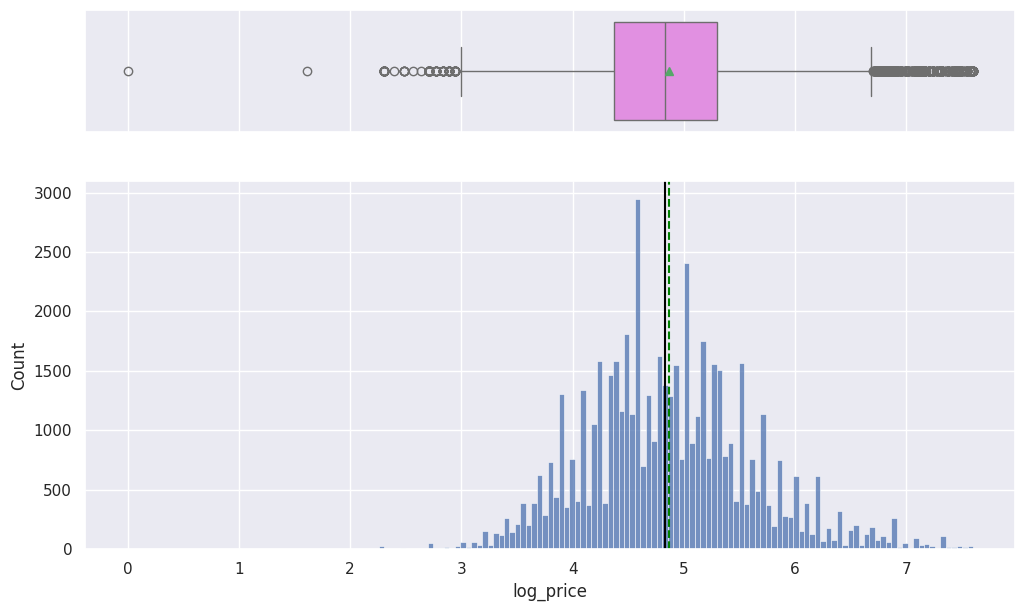

In [ ]:
histogram_boxplot(df, "log_price")

**Observations**

- *log_price* appears to be normally distributed.
- There are a few outliers both at the upper and lower ends.

**Actual rental price**

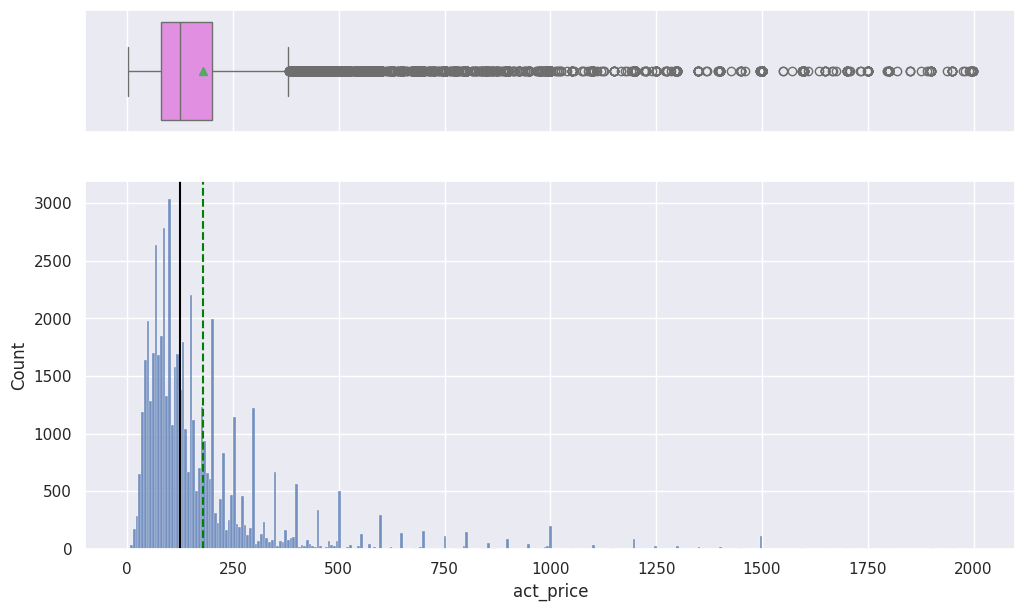

In [ ]:
df["act_price"] = np.exp(df["log_price"])
histogram_boxplot(df, "act_price")

**Observations**

- The actual rental price varies between 0 to 2000 dollars for the fixed period of time.
- Its distribution is right-skewed as there are many upper outliers. This indicates that the rents of many rooms are very high.
- We will using the log_price column for further analysis.

In [ ]:
# drop the act_price column
df.drop("act_price", axis=1, inplace=True)

***review_scores_rating***

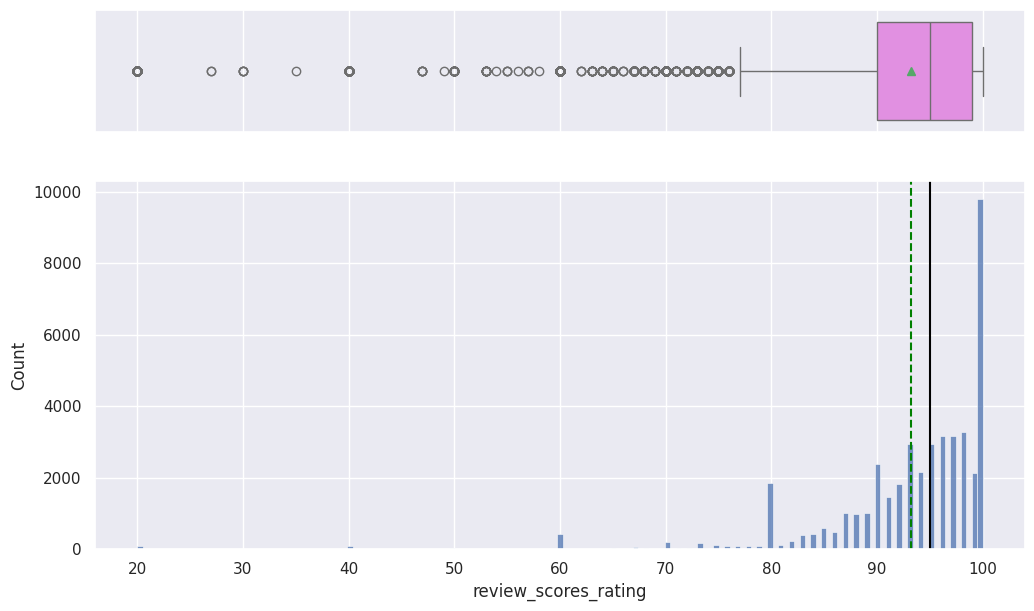

In [ ]:
histogram_boxplot(df, "review_scores_rating")

**Observations**

- The distribution of review score ratings is left-skewed, indicating that very few observations (or rooms) have less than 80 review score ratings.
- More than 50% of the rooms have a review score rating of more than 90.

***beds***

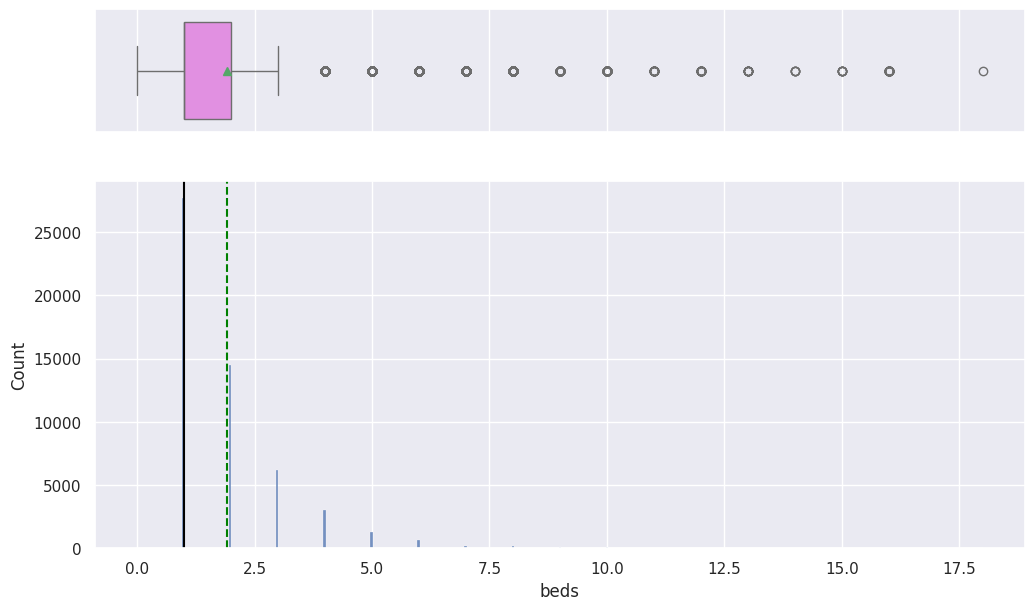

In [ ]:
histogram_boxplot(df, "beds")

* The columns seems to have a lot of discrete values.

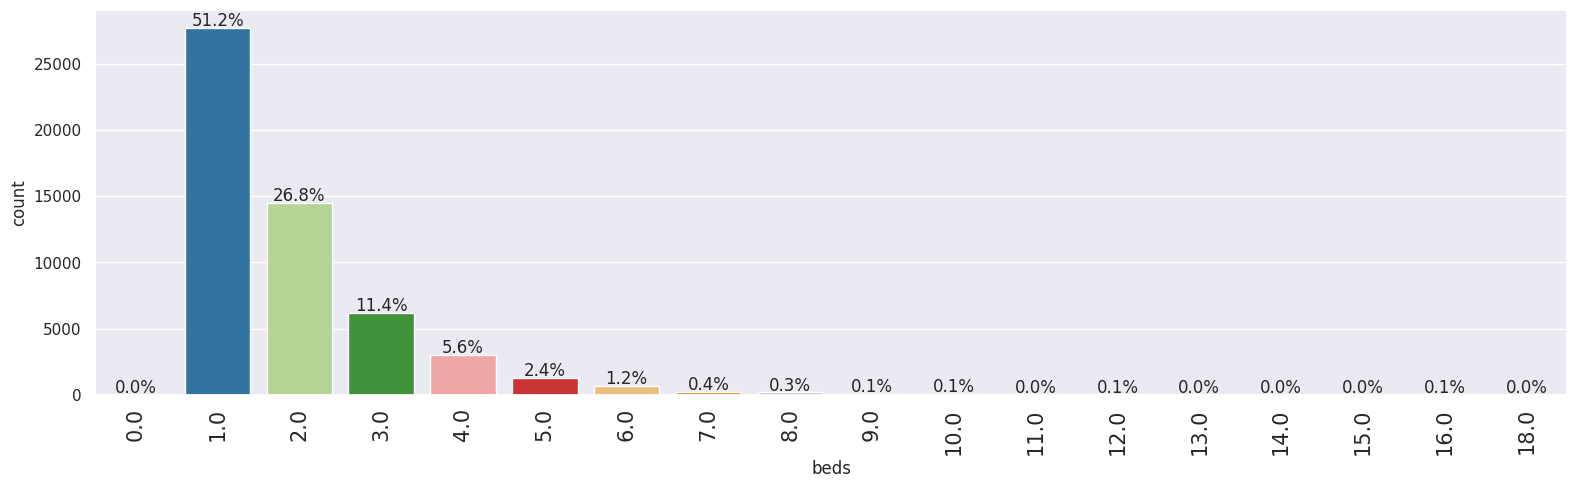

In [ ]:
labeled_barplot(df, "beds", perc=True)

- Majority of rental rooms (around 77%) have 1 or 2 beds.

***bedrooms***

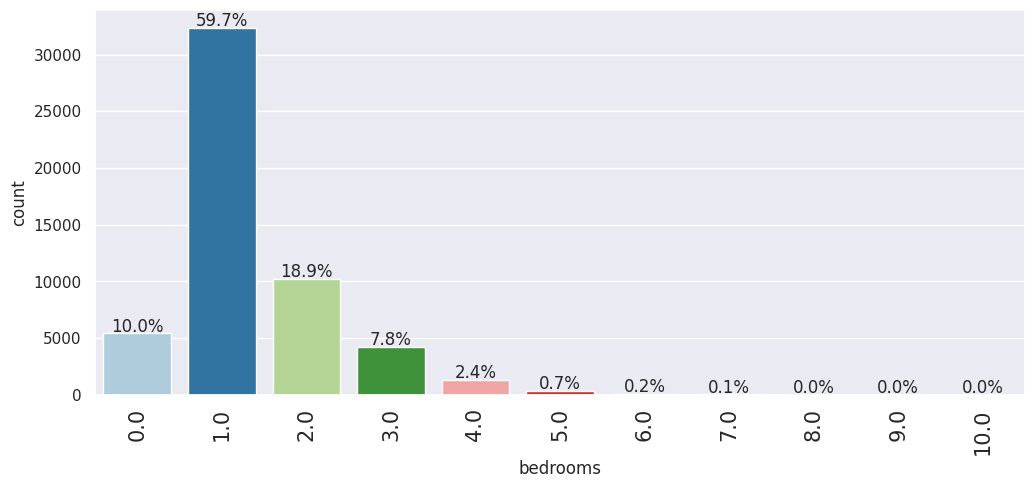

In [ ]:
labeled_barplot(df, "bedrooms", perc=True)

- About 80% of the rental rooms have 1 or 2 bedrooms.

***bathrooms***

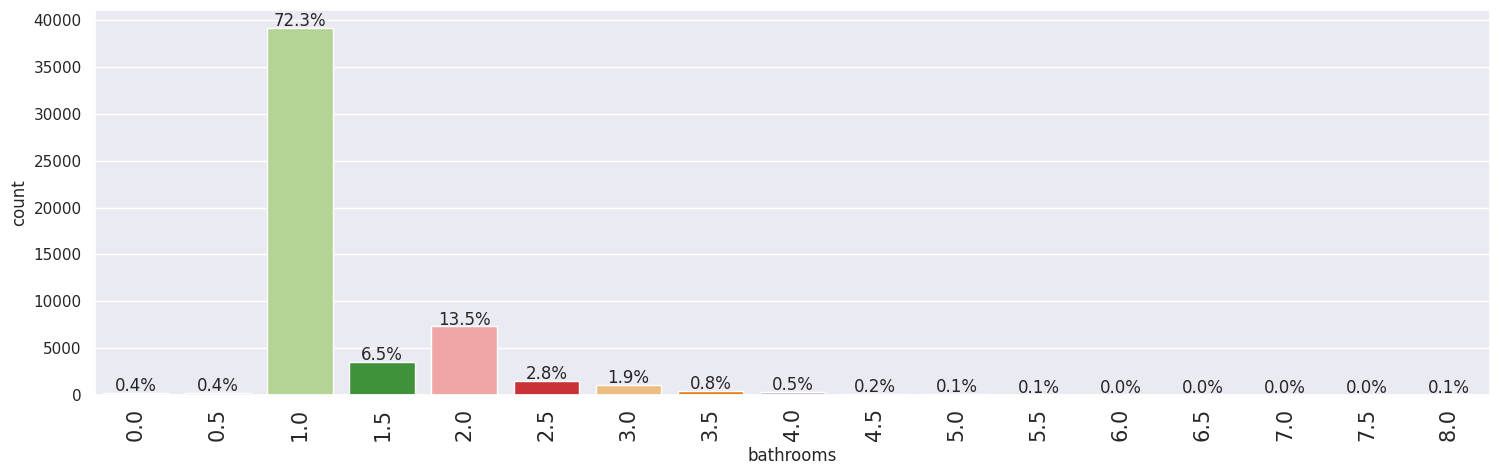

In [ ]:
labeled_barplot(df, "bathrooms", perc=True)

- Almost 90% of the rental rooms have 1, 1.5, or 2 bathrooms.

**How can the number of bathrooms be in decimals?**

From Wiki:

In the United States, bathrooms are generally categorized as the master bathroom, containing a varied shower and a tub that is adjoining to a master bedroom, a "full bathroom" (or "full bath"), containing four plumbing fixtures: bathtub/shower, or (separate shower), toilet, and sink; "half (1/2) bath" (or "powder room") containing just a toilet and sink; and "3/4 bath" containing toilet, sink, and shower, although the terms vary from market to market. In some U.S. markets, a toilet, sink, and shower are considered a "full bath". This lack of a single, universal definition commonly results in discrepancies between the advertised and actual number of baths in real estate listings. An additional complication is that there are currently two ways of notating the number of bathrooms in a dwelling. One method is to count a half bathroom as ".5" and then add this to the number of full bathrooms (e.g., "2.5" baths would mean 2 full baths and 1 half bath). The other, newer method is to put the number of full bathrooms to the left side of the decimal point and to put the number of half bathrooms to the right of the decimal point (e.g., "2.1" would mean 2 full baths and 1 half bath; "3.2" would mean 3 full baths and 2 half baths).

***accommodates***

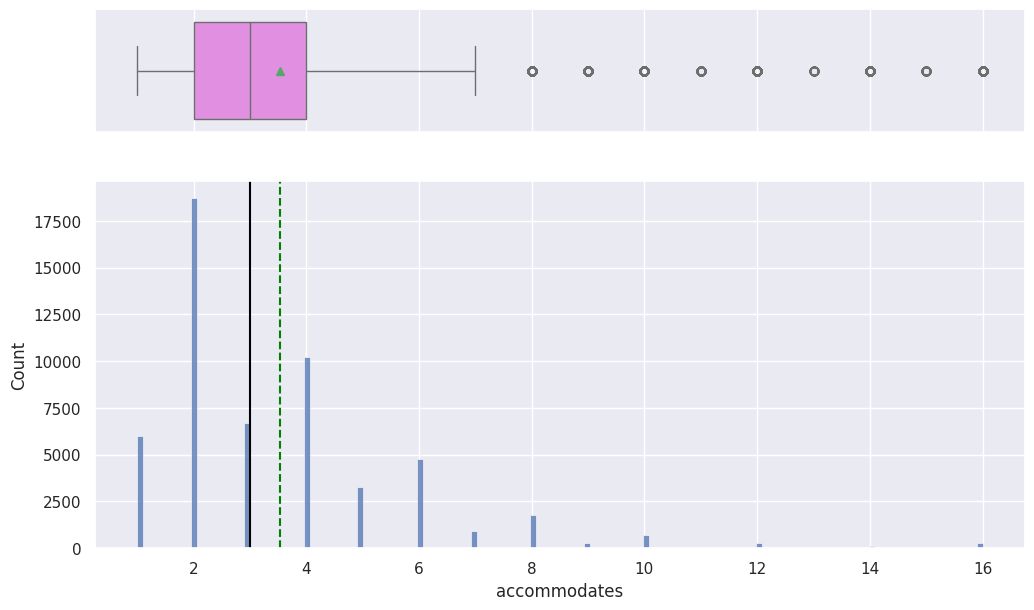

In [ ]:
histogram_boxplot(df, "accommodates")

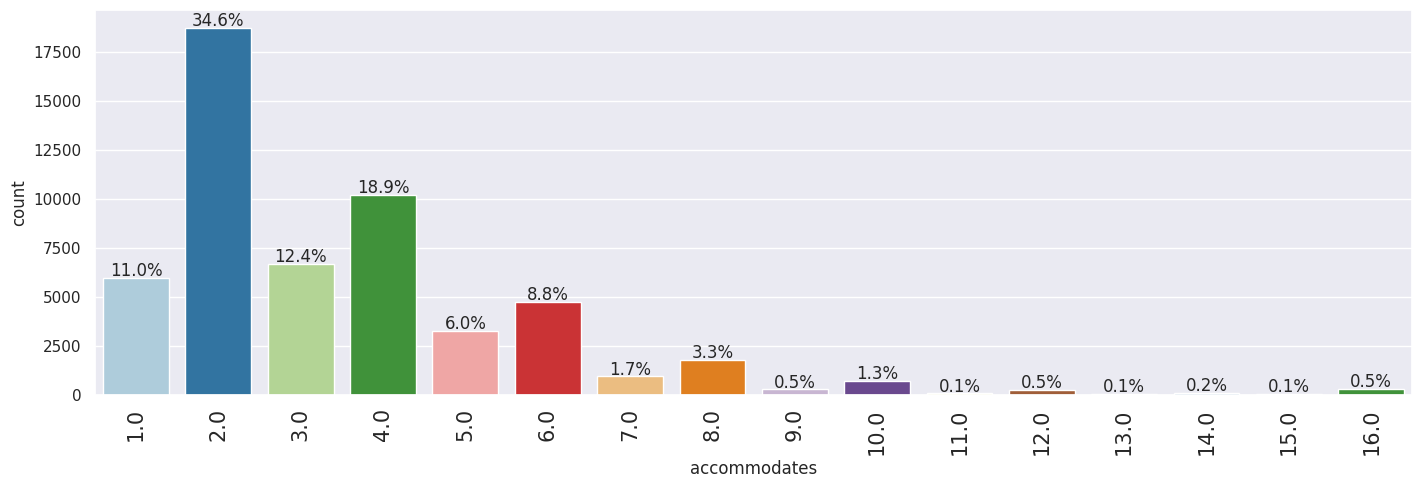

In [ ]:
labeled_barplot(df, "accommodates", perc=True)

- Almost 75% of the rooms can accommodates 4 or less than 4 people.

***room_type***

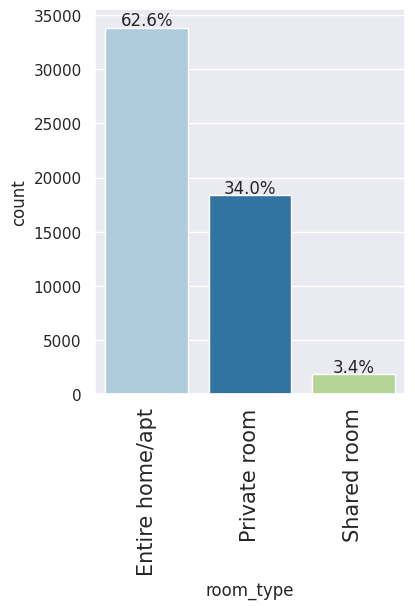

In [ ]:
labeled_barplot(df, "room_type", perc=True)

- Entire apartments or home is the most common type of rented rooms.

***cancellation_policy***

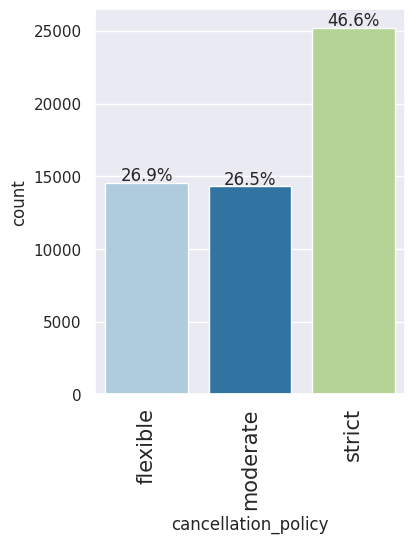

In [ ]:
labeled_barplot(df, "cancellation_policy", perc=True)

- Nearly 50% of the rooms have a strict cancellation policy.

***cleaning_fee***

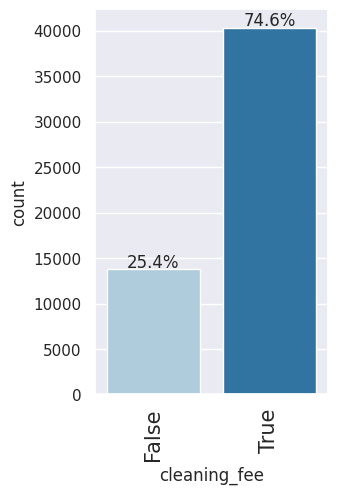

In [ ]:
labeled_barplot(df, "cleaning_fee", perc=True)

- 74.5% of the rooms have a cleaning fee.

***instant_bookable***

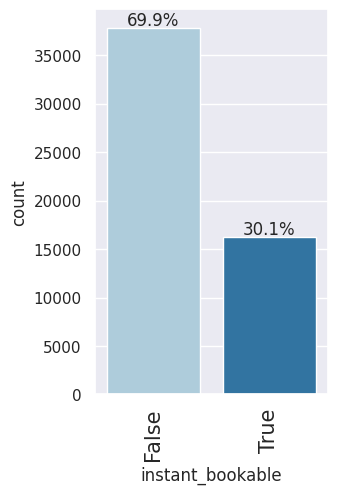

In [ ]:
labeled_barplot(df, "instant_bookable", perc=True)

- Nearly 70% of the rooms are not instantly bookable.

## Bivariate Analysis

**Let's check the correlation between numerical columns.**

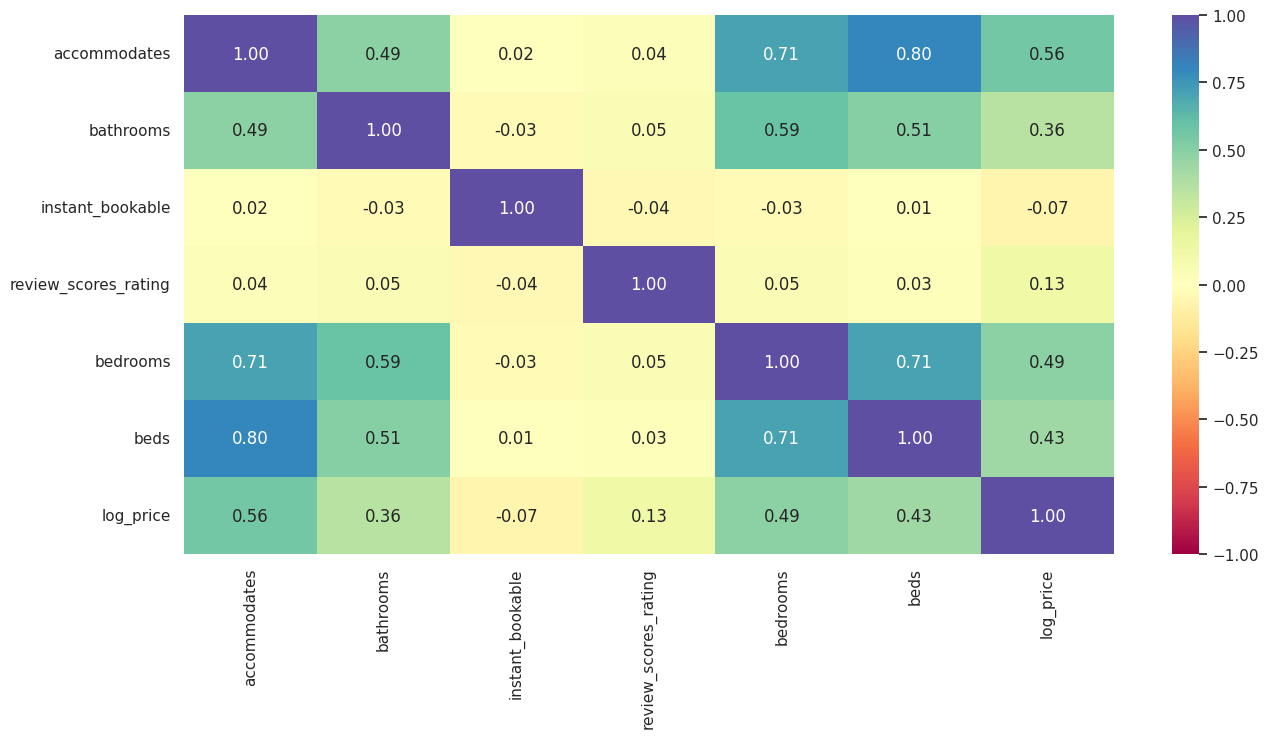

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations**

- *log_price* is moderately positively correlated with *accommodates* (0.56), *bedrooms* (0.49), and *beds* (0.43).
- *accommodates* and *beds* have slightly high positive correlation.

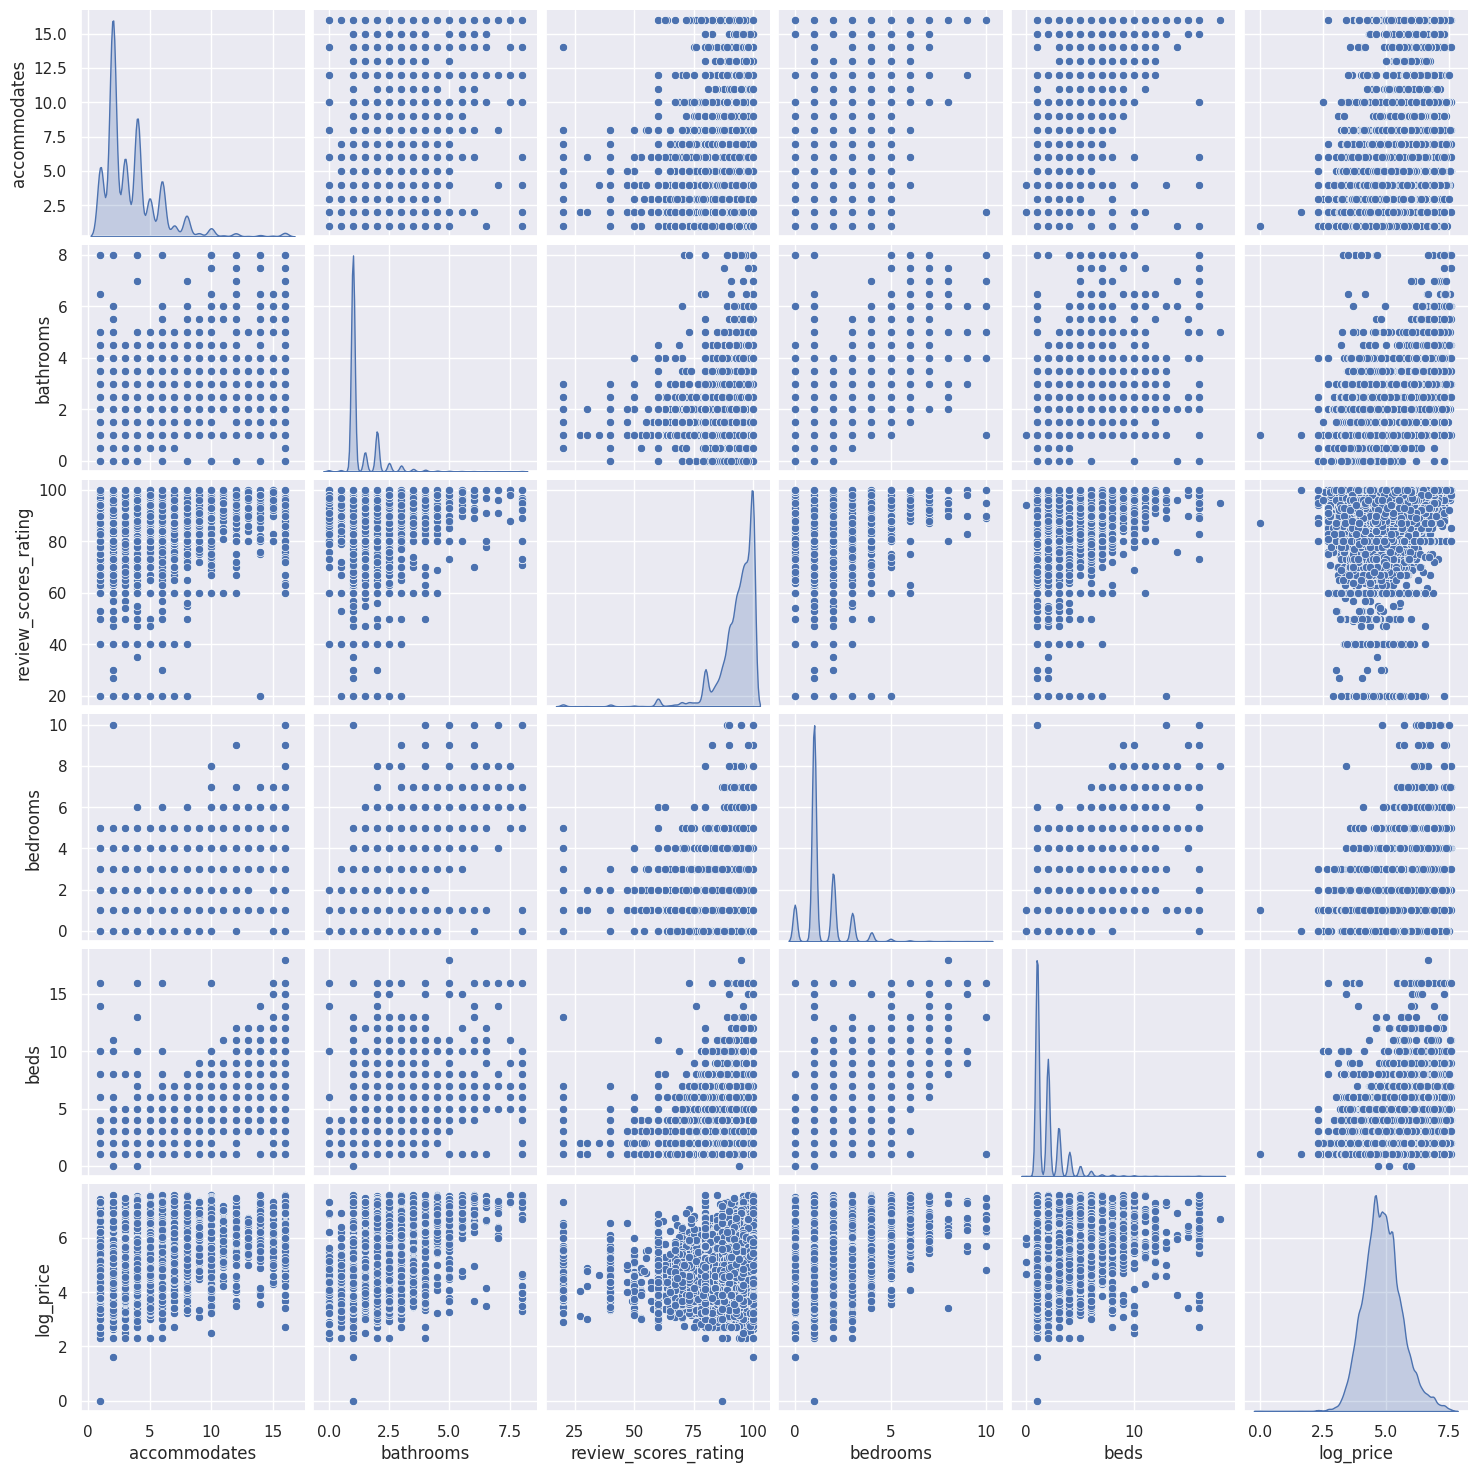

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
sns.pairplot(data=df[numeric_columns], diag_kind="kde")
plt.show()

- As observed previously, the distribution log_price is close to normal.

**Let's check the variation in *log_price* with some of the other variables.**

***accommodates* vs *log price***

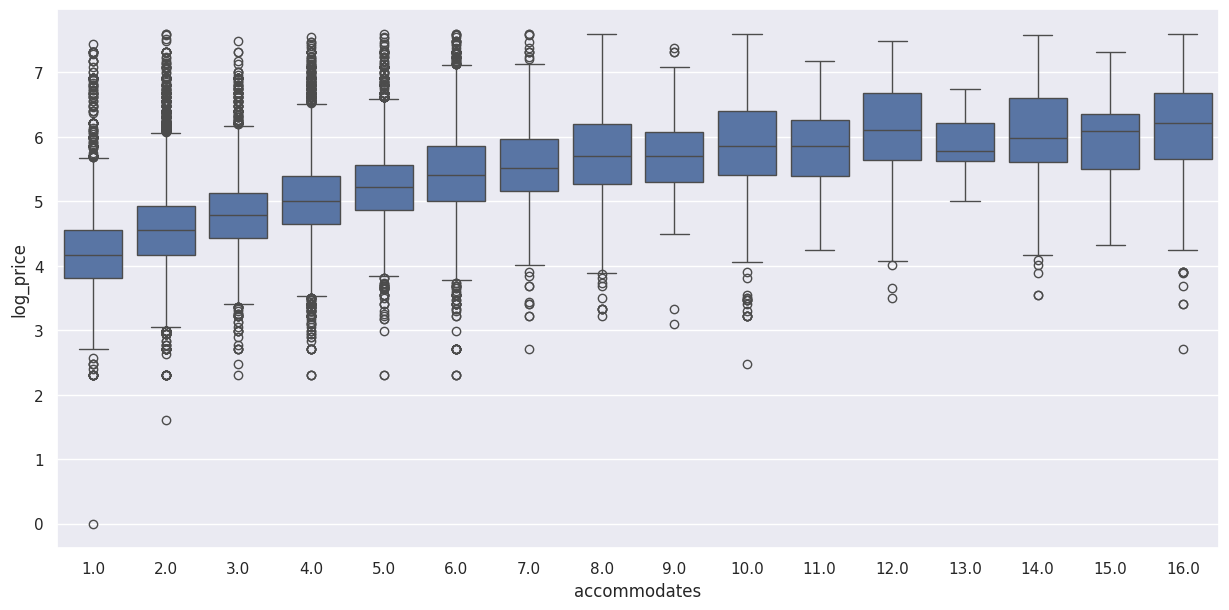

In [ ]:
plt.figure(figsize=(15, 7))
sns.boxplot(x="accommodates", y="log_price", data=df)
plt.show()

**Observations**

- Rooms allowing a higher accommodates have higher rental price.
- As the number of accommodates increases, rental price also increases.

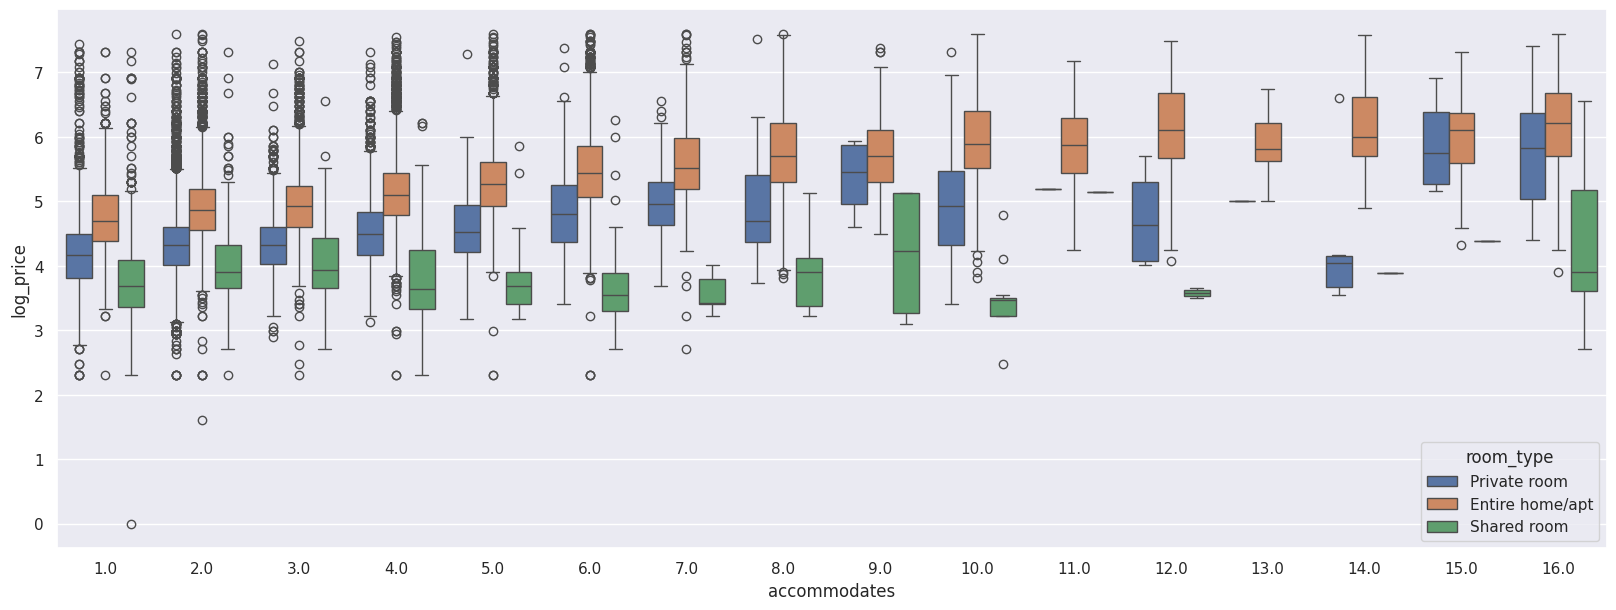

In [ ]:
plt.figure(figsize=(20, 7))
sns.boxplot(x="accommodates", y="log_price", data=df, hue="room_type")
plt.show()

**Observations**

- In general, the rental price for an entire home/apartment is more than the price of private rooms, which is again more than that of shared rooms.
- There are more upper outliers in terms of the rental price for entire rooms/apt which allow accommodation for 7 or fewer people. This indicates a higher rental price for some rooms.

***bedrooms* vs *log_price***

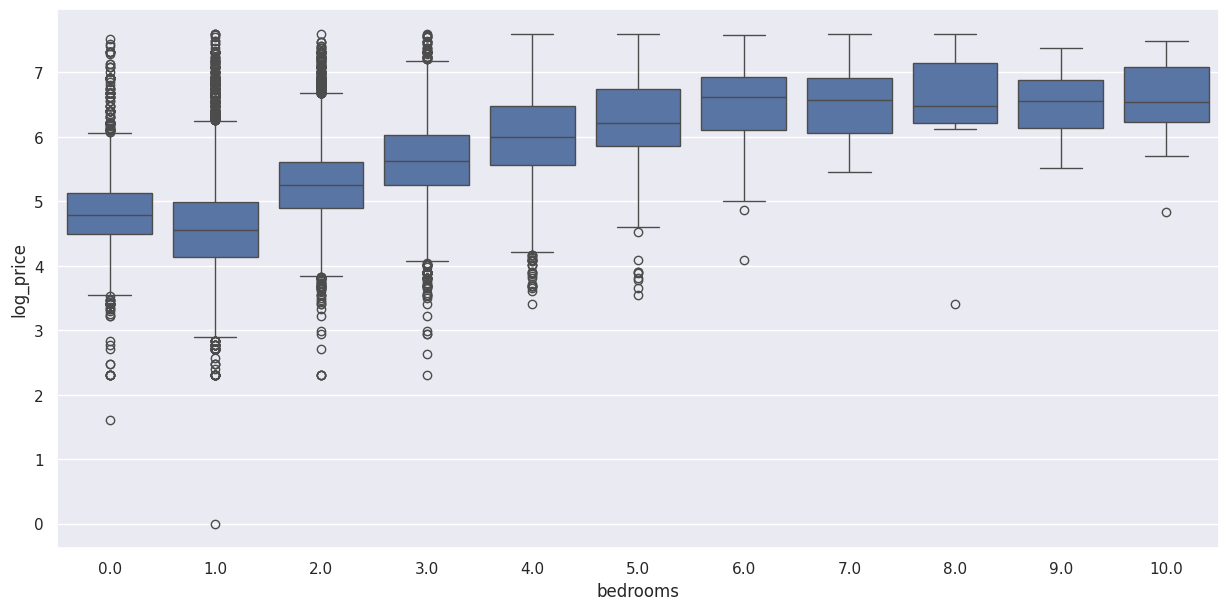

In [ ]:
plt.figure(figsize=(15, 7))
sns.boxplot(x="bedrooms", y="log_price", data=df)
plt.show()

- The rental price increases as the number of bedrooms increases.

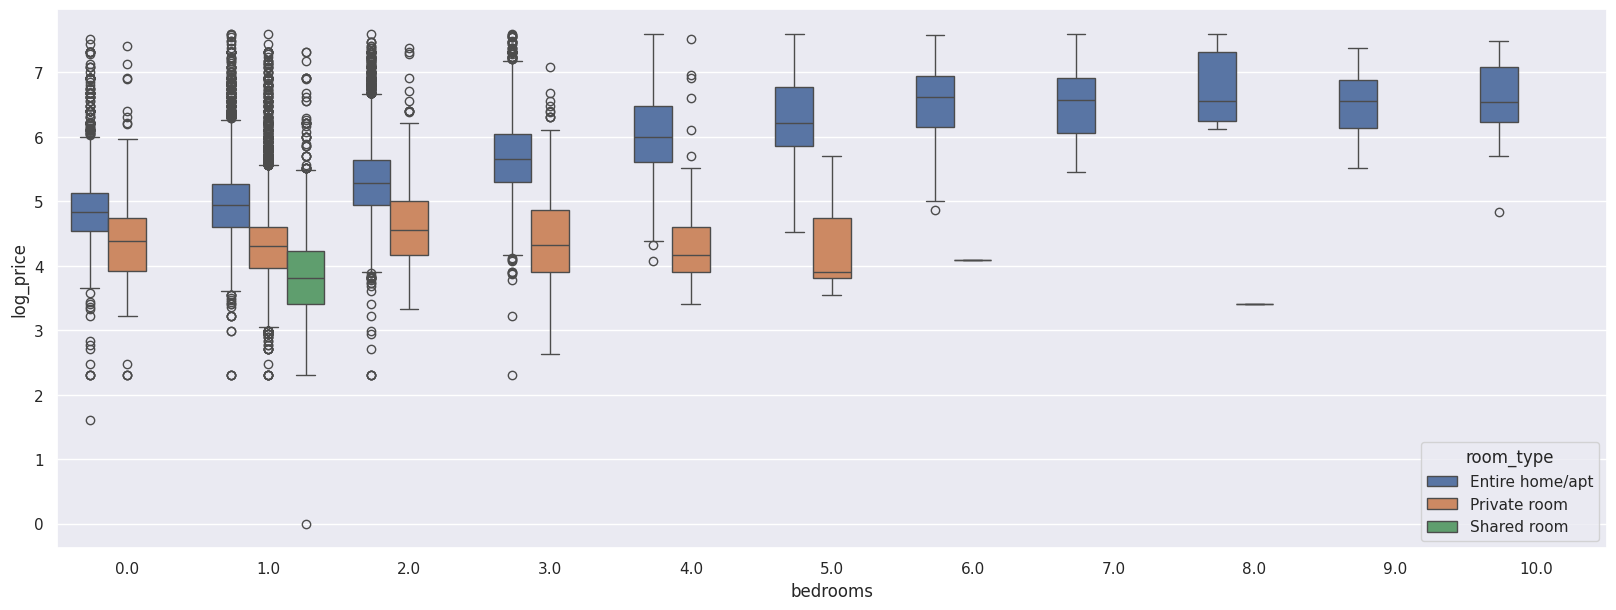

In [ ]:
plt.figure(figsize=(20, 7))
sns.boxplot(x="bedrooms", y="log_price", data=df, hue="room_type")
plt.show()

**Observations**

- Shared rental rooms have only 1 bedroom.
- The rental price of entire homes or apartments is greater than that of private rooms, irrespective of the number of bedrooms.

## Data Preprocessing

### Missing Value Treatment

In [ ]:
df.isnull().sum()

,0
room_type,5
accommodates,3
bathrooms,195
cancellation_policy,8
cleaning_fee,4
instant_bookable,0
review_scores_rating,10215
bedrooms,92
beds,125
log_price,0


**Observation**

- There are missing values in both numerical and categorical columns.
- We will drop the missing values in non-numerical columns.
- We will impute missing values in numerical columns with column median grouped by *room_type*.

In [ ]:
# list of columns for which missing values will be dropped
nonnumeric_columns = df.select_dtypes(exclude=np.number).columns
df.dropna(subset=nonnumeric_columns, inplace=True)

In [ ]:
df.isnull().sum()

,0
room_type,0
accommodates,0
bathrooms,192
cancellation_policy,0
cleaning_fee,0
instant_bookable,0
review_scores_rating,10211
bedrooms,92
beds,125
log_price,0


In [ ]:
# list of columns for which missing values will be imputed
numeric_columns.remove("log_price")

# Impute missing values in numerical columns with median grouped by room_type

df[numeric_columns] = df.groupby(["room_type"])[numeric_columns].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
df.isnull().sum()

,0
room_type,0
accommodates,0
bathrooms,0
cancellation_policy,0
cleaning_fee,0
instant_bookable,0
review_scores_rating,0
bedrooms,0
beds,0
log_price,0


- Missing values have now been dealt with.
- Let's check the statistical summary of the data once.

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
room_type,54104,3,Entire home/apt,33848,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,54104.0,NaN,NaN,NaN,3.52619,2.343964,1.0,2.0,3.0,4.0,16.0
bathrooms,54104.0,NaN,NaN,NaN,1.303776,0.650292,0.0,1.0,1.0,1.5,8.0
cancellation_policy,54104,3,strict,25211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cleaning_fee,54104,2,True,40342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
instant_bookable,54104,2,False,37828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_scores_rating,54104.0,NaN,NaN,NaN,93.648917,7.611323,20.0,92.0,96.0,98.0,100.0
bedrooms,54104.0,NaN,NaN,NaN,1.362746,0.950863,0.0,1.0,1.0,2.0,10.0
beds,54104.0,NaN,NaN,NaN,1.916254,1.383276,0.0,1.0,1.0,2.0,18.0
log_price,54104.0,NaN,NaN,NaN,4.865802,0.75579,0.0,4.369448,4.828314,5.298317,7.600402


- The target variable *log_price* has a few values equal to 0. We will add a small positive value to them to avoid problems while checking the model performance.
- We will also convert the boolean columns to integer type.

In [ ]:
# adding small positive value to log_price
eps = 1e-06
df["log_price"] = df["log_price"] + eps

df["log_price"].describe()

,log_price
count,54104.000000
mean,4.865803
std,0.755790
min,0.000001
25%,4.369449
50%,4.828315
75%,5.298318
max,7.600403


In [ ]:
# converting the boolean columns to integer type
bool_cols = ["cleaning_fee", "instant_bookable"]
df[bool_cols] = df[bool_cols].astype(int)
df.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3.0,1.0,strict,1,0,100.0,1.0,1.0,5.010636
1,Entire home/apt,7.0,1.0,strict,1,1,93.0,3.0,3.0,5.129900
2,Entire home/apt,5.0,1.0,moderate,1,1,92.0,1.0,3.0,4.976735
3,Entire home/apt,4.0,1.0,flexible,1,0,96.0,2.0,2.0,6.620074
4,Entire home/apt,2.0,1.0,moderate,1,1,40.0,0.0,1.0,4.744933


### Outlier Detection

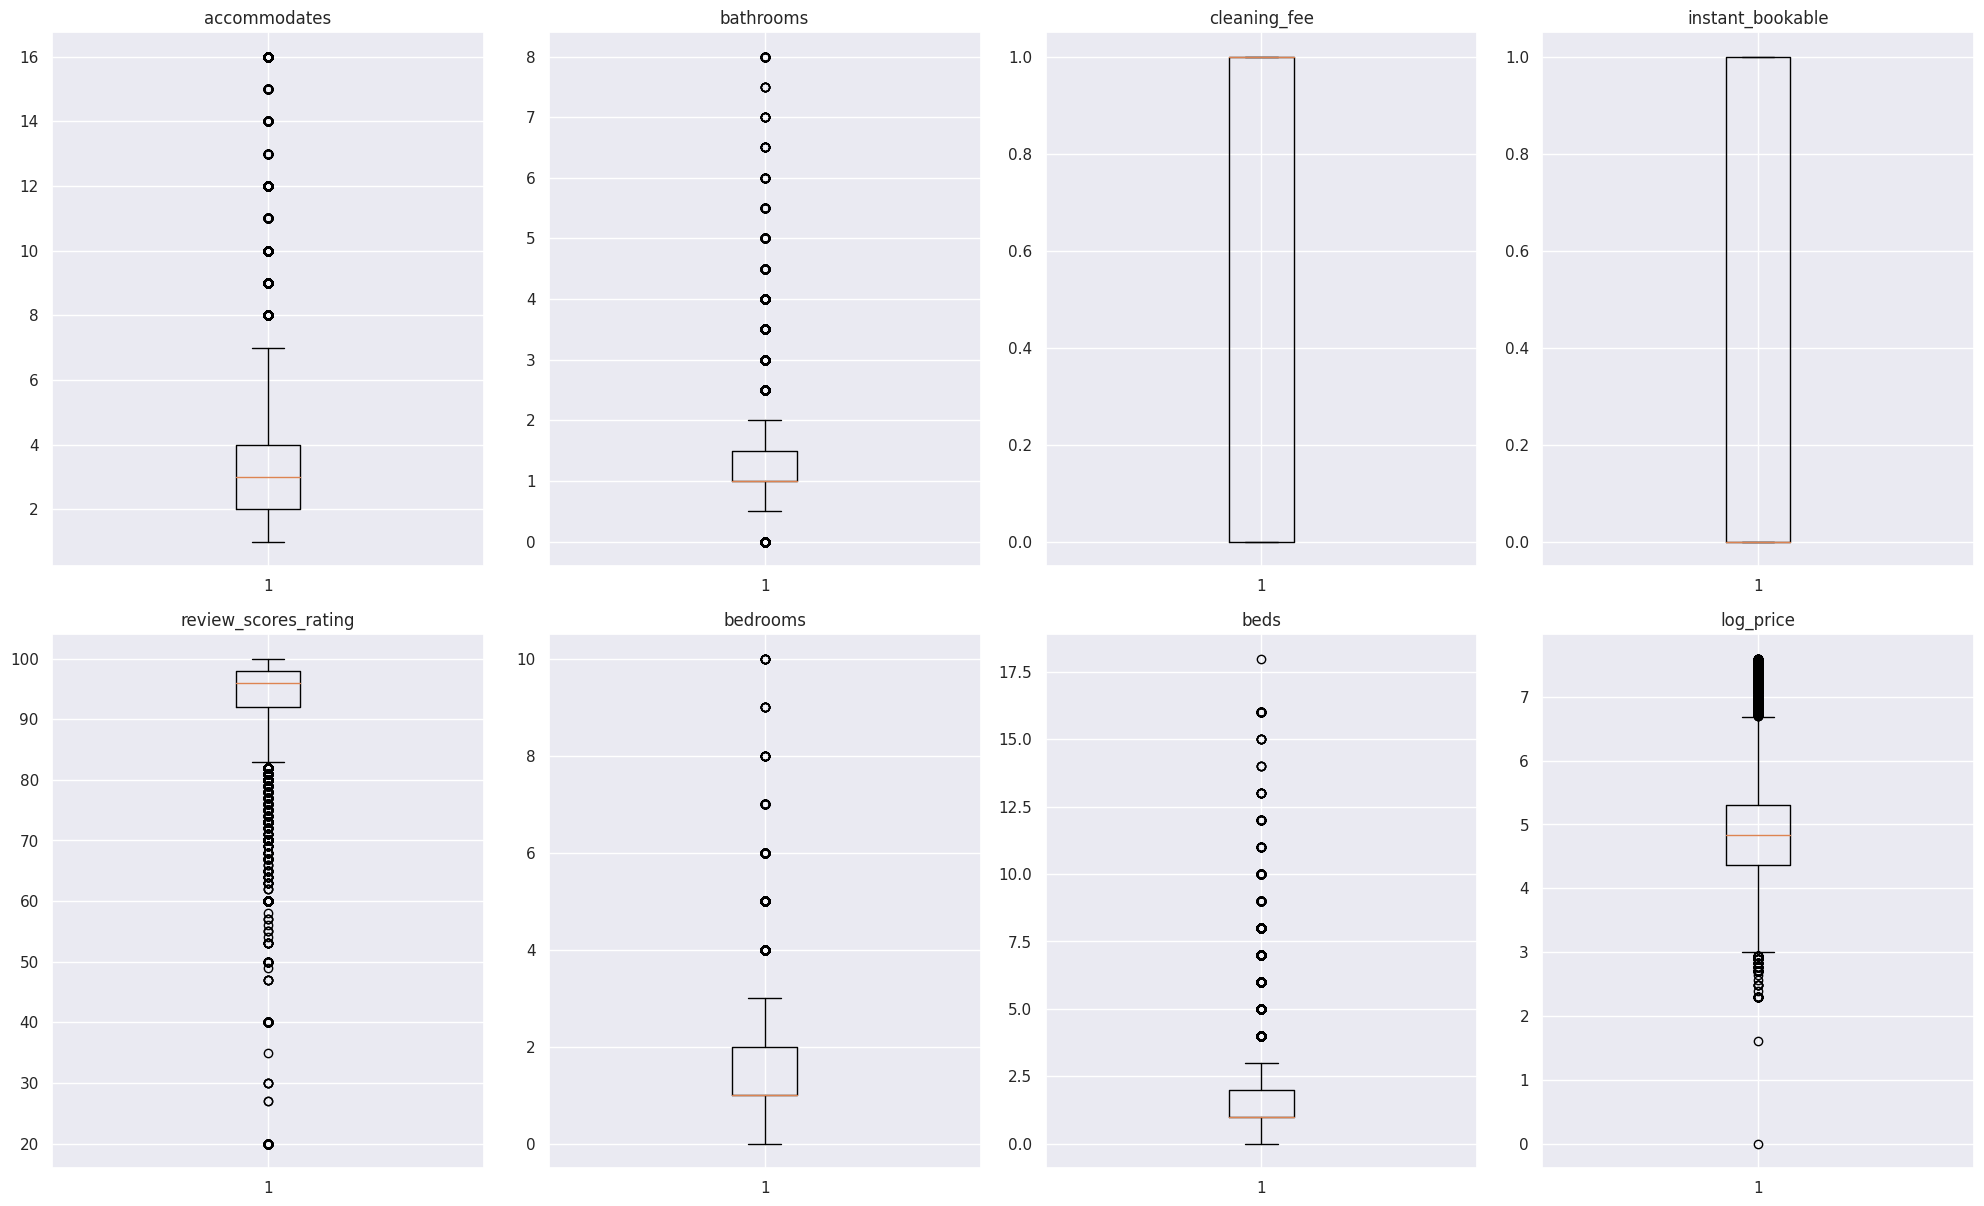

In [ ]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number)
plt.figure(figsize=(20, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(5, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations**

- All numerical variables have outliers.
- *accommodates*, *bedrooms*, and *beds* have only upper outliers.
- Reviews score have only lower outliers.
- *log_price* has both upper and lower outliers.

### Outlier Treatment

- Let's treat all the outliers by flooring and capping.

In [ ]:
def treat_outliers(df, col):
    """
    treats outliers in a varaible
    col: str, name of the numerical varaible
    df: data frame
    col: name of the column
    """
    Q1 = df[col].quantile(0.25)  # 25th quantile
    Q3 = df[col].quantile(0.75)  # 75th quantile
    IQR = Q3 - Q1
    Lower_Whisker = Q1 - 1.5 * IQR
    Upper_Whisker = Q3 + 1.5 * IQR
    df[col] = np.clip(
        df[col], Lower_Whisker, Upper_Whisker
    )  # all the values samller than Lower_Whisker will be assigned value of Lower_whisker
    # and all the values above upper_whishker will be assigned value of upper_Whisker
    return df


def treat_outliers_all(df, col_list):
    """
    treat outlier in all numerical varaibles
    col_list: list of numerical varaibles
    df: data frame
    """
    for c in col_list:
        df = treat_outliers(df, c)

    return df

In [ ]:
# treating the outliers
numerical_col = df.select_dtypes(include=np.number).columns.tolist()
df = treat_outliers_all(df, numerical_col)

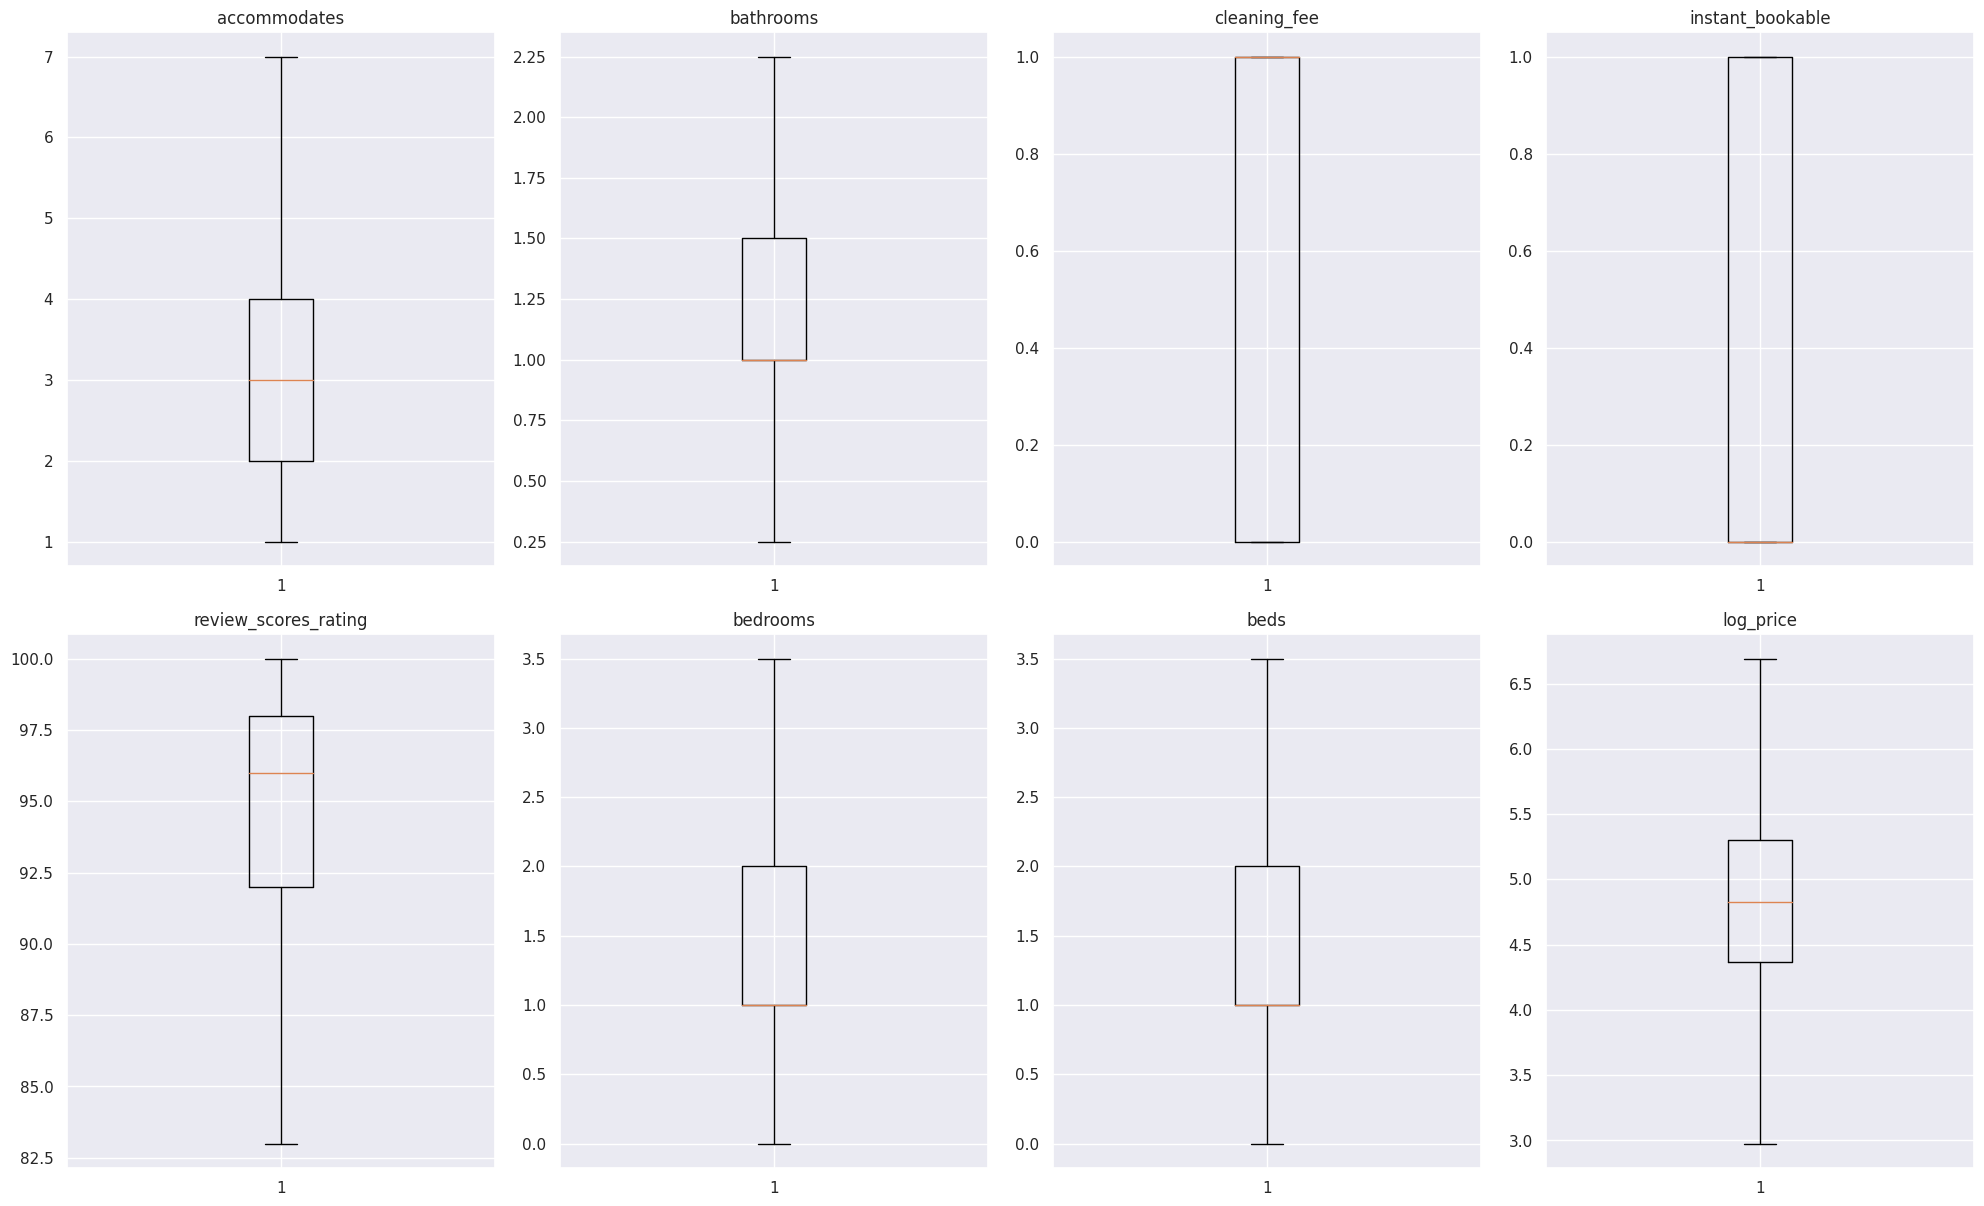

In [ ]:
# let's look at the boxplots to see if the outliers have been treated or not
plt.figure(figsize=(20, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(5, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

## Model Building - Linear Regression


### Model Performance Check

**Let's check the performance of the model using different metrics.**

* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
* We will define a function to calculate MAPE and adjusted $R^2$.    
* We will create a function which will print out all the above metrics in one go.

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

## Linear Model Building

1. We want to predict the log of rental price.

2. Before we proceed to build a model, we'll have to encode categorical features.

3. We'll split the data into train and test to be able to evaluate the model that we build on the train data.

4. We will build a Linear Regression model using the train data and then check it's performance.

### Data Preparation for modeling with log_price as Dependent variable

In [ ]:
# defining the dependent and independent variables
X = df.drop(["log_price"], axis=1)
y = df["log_price"]

In [ ]:
# creating dummy variables
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)

X = X.astype(float)

X.head()

,accommodates,bathrooms,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,room_type_Private room,room_type_Shared room,cancellation_policy_moderate,cancellation_policy_strict
0,3.0,1.0,1.0,0.0,100.0,1.0,1.0,0.0,0.0,0.0,1.0
1,7.0,1.0,1.0,1.0,93.0,3.0,3.0,0.0,0.0,0.0,1.0
2,5.0,1.0,1.0,1.0,92.0,1.0,3.0,0.0,0.0,1.0,0.0
3,4.0,1.0,1.0,0.0,96.0,2.0,2.0,0.0,0.0,0.0,0.0
4,2.0,1.0,1.0,1.0,83.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
# splitting the data in 70:30 ratio for train to test data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [ ]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 37872
Number of rows in test data = 16232


### Model Building - Linear Regression with log_price as Dependent variable

In [ ]:
# fitting the linear model
lin_reg_model = LinearRegression()
lin_reg_model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Checking model performance on train set
lin_reg_model_perf_train = model_performance_regression(lin_reg_model, x_train, y_train)
lin_reg_model_perf_train

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.515716,0.400831,0.509462,0.50932,8.405174


In [ ]:
# Checking model performance on test set
lin_reg_model_perf_test = model_performance_regression(lin_reg_model, x_test, y_test)
lin_reg_model_perf_test

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.515605,0.398738,0.508053,0.50772,8.320527


**Observations**

* Root Mean Squared Error of train and test data is somewhat similar.
* Mean Absolute Error indicates that our current model is able to predict the log of rental price within mean error of 0.4 on test data.
* The units of both RMSE and MAE are the same.
* Mean Absolute Percentage Error is ~8.3% on the test data.

## Business Insights and Recommendations

- With our linear regression model we have been able to capture ~51% of the variation in our data.


- Our final linear regression model has a MAPE of 8.3% on the test data, which means that we are able to predict within 8.3% of the rental price.


- Renting our rooms which can accommodate more people will fetch more revenue. Such rooms will generally be entire homes/apartments.


- The focus should be on providing a comfortable stay and better service to the customers to drive the review score ratings higher.


- We should explore data from other periods of time and about the ratings of services offered (dining, laundry, etc.). An analysis of the text reviews can also be conducted to gain an understanding of customer sentiment.



- We will also have to analyze the cost side of things before we can talk about profitability in the business. We should gather data regarding that.